In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
from skimage.draw import disk
from matplotlib.patches import Circle
import matplotlib.pyplot as plt

In [ ]:
def plot_histogram(df, column, bins=50,
                   xlabel=None,
                   title=None,
                   figsize=(4, 3),
                   dpi=150,
                   threshold = 0):

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    ax.hist(
        df[column].dropna(),
        bins=bins,
        edgecolor="black",
        linewidth=0.5,
        alpha=0.8
    )

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(title, fontsize=12)

    ax.axvline(threshold, linestyle="--", linewidth=2)

    # Clean style
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()
    
def draw_foci(image_path, df, showplot = True, save_image = True, save_path = ""):
    # Load image
    image = Image.open(image_path)
    arr = np.array(image) # convert image to numpy matrix

    # Plot image
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(arr, cmap="gray")

    # Draw red circles
    for _, row in df.iterrows():
        x = row["x_pixel"]
        y = row["y_pixel"]
        r = row["sigma_pixel"]

        circle = Circle(
            (x, y),
            r,
            fill=False,
            edgecolor="red",
            linewidth=0.25
        )

        ax.add_patch(circle)

    # Match image coordinates
    ax.set_xlim(0, arr.shape[1])
    ax.set_ylim(arr.shape[0], 0)

    # Save image
    if save_image: 
        plt.savefig(save_path,
            dpi=300,
            bbox_inches="tight"
        )
        
        # Do not display image
        #plt.close(fig)

    # Show image
    if showplot:
        plt.show(fig)

In [3]:
df = pd.read_csv("foci.csv")
df.columns = df.columns.str.strip()  # remove hidden spaces in headers
df = df.rename(columns={"x [nm]": "x_nm",
                            "y [nm]": "y_nm",
                            "sigma [nm]": "sigma_nm",
                            "intensity [photon]": "intensity_photon"}) # Rename columns

In [4]:
image_path = "img.tif" # load image

In [5]:
def foci_one_image(image_path, df, px_size_nm, plot = True, save_path = ""):
    image = Image.open(image_path)  # load image
    arr = np.array(image) # convert image to numpy matrix
    H, W = arr.shape # get number of pixels (512*512 for 16-bit image)

    # Storage lists
    x_list = []
    y_list = []
    sigma_list = []
    mean_list = []
    sd_list = []

    # Prepare dataframe
    df.columns = df.columns.str.strip()  # remove hidden spaces in headers
    df = df.rename(columns={"x [nm]": "x_nm",
                            "y [nm]": "y_nm",
                            "sigma [nm]": "sigma_nm",
                            "intensity [photon]": "intensity_photon"}) # Rename columns

    # Iteration through the thunderSTORM dataframe
    for _, row in df.iterrows():
        x_px = int(row["x_nm"] / px_size_nm)
        y_px = int(row["y_nm"] / px_size_nm)
        r_px = max(1, int(row["sigma_nm"] / px_size_nm)) # minimal possible value for radius is 1 pixel!

        # Build circular mask (clipped automatically)
        rr, cc = disk((y_px, x_px), r_px, shape=(H, W))
        mask = np.zeros((H, W), dtype=bool)
        mask[rr, cc] = True

        n_pixels_mask = np.sum(mask)

        # Compute mean intensity
        if n_pixels_mask > 0:
            mean_intensity = arr[mask].mean()
            sd_intensity = arr[mask].std()
        else:
            mean_intensity = np.nan

        # Add values to the corresponding lists
        x_list.append(x_px)
        y_list.append(y_px)
        sigma_list.append(r_px)
        mean_list.append(mean_intensity)
        sd_list.append(sd_intensity)
    
    # Return modified copy
    df_out = df.copy()
    df_out["x_pixel"] = x_list
    df_out["y_pixel"] = y_list
    df_out["sigma_pixel"] = sigma_list
    df_out["foci_MFI"] = mean_list
    df_out["foci_SD"] = sd_list

    # Make a plot
    if plot:
        draw_foci(image_path = image_path,
                  df = df_out,
                  showplot = False,
                  save_image = True,
                  save_path = save_path)

    return df_out


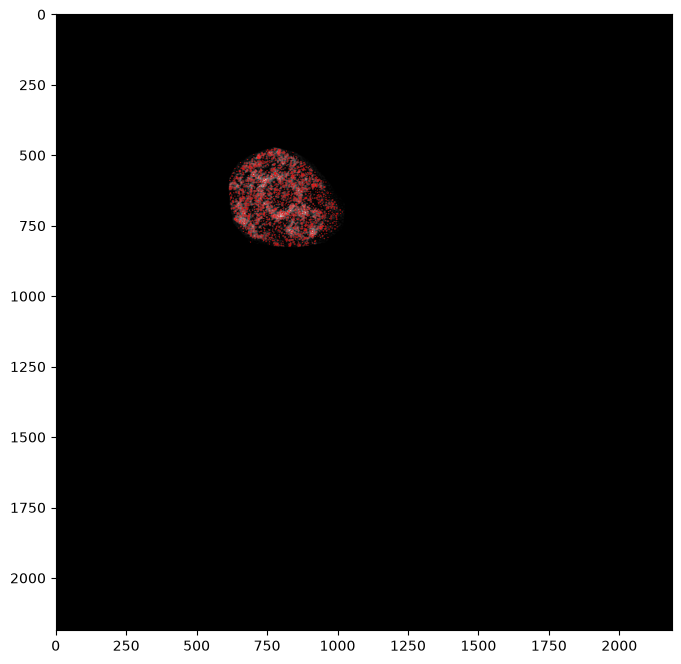

In [6]:
df_processed = foci_one_image(image_path, df, px_size_nm = 35.3, plot = True, save_path = "")

In [7]:
df_processed = df_processed[df_processed['sigma_nm'] > 90] # filtration resolution limit
new = df_processed[df_processed['foci_MFI'] / df_processed['foci_SD'] > 5] # filtration of foci with low MFI/SD ratio

In [10]:
new

,id,x_nm,y_nm,sigma_nm,intensity_photon,uncertainty_xy [nm],x_pixel,y_pixel,sigma_pixel,foci_MFI,foci_SD
4,5,21878.75294,21583.25323,128.72460,119975.82050,1.75059,619,611,3,335.600000,27.947093
5,6,21868.07416,21870.24584,141.53574,104504.23762,2.22061,619,619,4,241.888889,19.261040
8,9,21939.65063,21290.67108,122.27963,100010.68932,2.80244,621,603,3,358.000000,43.951792
12,13,21946.19994,21823.50595,136.98386,96832.67562,3.25403,621,618,3,243.560000,16.370901
13,14,22002.16750,22913.93132,105.12881,39231.85348,2.27521,623,649,2,169.555556,8.693690
...,...,...,...,...,...,...,...,...,...,...,...
1281,1282,34729.38495,26144.86282,97.66742,20168.44701,2.64393,983,740,2,101.111111,12.215149
1282,1283,34831.13464,25086.63887,106.74904,25496.30514,3.34970,986,710,3,101.880000,13.753021
1285,1286,34937.93157,24145.55142,99.75673,36404.15323,3.28935,989,684,2,178.111111,14.019387
1289,1290,35127.88406,25216.10392,93.19066,24455.49376,2.45140,995,714,2,133.777778,12.434520


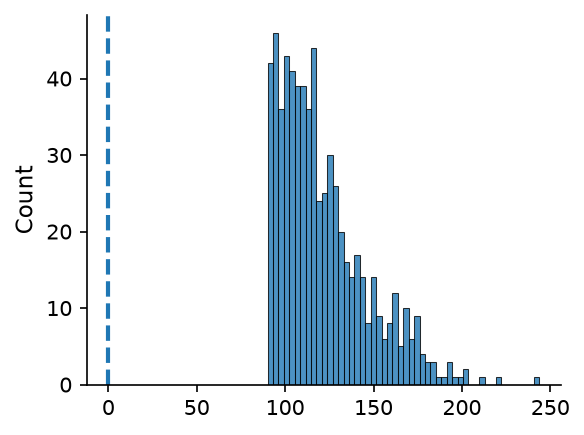

In [13]:
plot_histogram(new, column="sigma_nm", bins=50, xlabel="", title="", threshold=0)

In [18]:
def circles_overlap(c1, c2):
    x1, y1, r1 = c1
    x2, y2, r2 = c2

    distance = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

    return distance < r1 + r2

In [19]:
circles = [
    (100, 100, 20),
    (110, 105, 10),
    (200, 200, 15),
    (205, 205, 25),
    (400, 400, 10)
]


In [ ]:
def overlap_fraction(c1, c2):
    """
    c1, c2 = (x, y, radius)

    Возвращает долю площади МЕНЬШЕГО круга,
    которая перекрывается другим кругом.
    """

    x1, y1, r1 = c1
    x2, y2, r2 = c2

    # Расстояние между центрами
    d = np.hypot(x1 - x2, y1 - y2)

    # 1. Круги вообще не пересекаются
    if d >= r1 + r2:
        return 0.0

    # Радиус меньшего круга
    r_small = min(r1, r2)

    # 2. Меньший круг полностью находится внутри большего
    if d <= abs(r1 - r2):
        return 1.0

    # 3. Частичное пересечение
    alpha = np.arccos(
        (d**2 + r1**2 - r2**2) / (2 * d * r1)
    )

    beta = np.arccos(
        (d**2 + r2**2 - r1**2) / (2 * d * r2)
    )

    intersection_area = (
        r1**2 * alpha
        + r2**2 * beta
        - 0.5 * np.sqrt(
            (-d + r1 + r2)
            * (d + r1 - r2)
            * (d - r1 + r2)
            * (d + r1 + r2)
        )
    )

    small_area = np.pi * r_small**2

    return intersection_area / small_area

In [34]:
def remove_overlapping_circles(
    df,
    x_col="X",
    y_col="Y",
    radius_col="Radius",
    threshold=0.8
):
    # Work on a copy
    df = df.copy()

    # Check larger circles first
    sorted_indices = df[radius_col].sort_values(ascending=False).index

    selected_indices = []

    for idx in sorted_indices:

        circle = (
            df.loc[idx, x_col],
            df.loc[idx, y_col],
            df.loc[idx, radius_col]
        )

        remove = False

        for selected_idx in selected_indices:

            bigger_circle = (
                df.loc[selected_idx, x_col],
                df.loc[selected_idx, y_col],
                df.loc[selected_idx, radius_col]
            )

            overlap = overlap_fraction(circle, bigger_circle)

            if overlap > threshold:
                remove = True
                break

        if not remove:
            selected_indices.append(idx)

    # Keep only circles that survived
    return df.loc[selected_indices].sort_index()

In [32]:
new

,id,x_nm,y_nm,sigma_nm,intensity_photon,uncertainty_xy [nm],x_pixel,y_pixel,sigma_pixel,foci_MFI,foci_SD
4,5,21878.75294,21583.25323,128.72460,119975.82050,1.75059,619,611,3,335.600000,27.947093
5,6,21868.07416,21870.24584,141.53574,104504.23762,2.22061,619,619,4,241.888889,19.261040
8,9,21939.65063,21290.67108,122.27963,100010.68932,2.80244,621,603,3,358.000000,43.951792
12,13,21946.19994,21823.50595,136.98386,96832.67562,3.25403,621,618,3,243.560000,16.370901
13,14,22002.16750,22913.93132,105.12881,39231.85348,2.27521,623,649,2,169.555556,8.693690
...,...,...,...,...,...,...,...,...,...,...,...
1281,1282,34729.38495,26144.86282,97.66742,20168.44701,2.64393,983,740,2,101.111111,12.215149
1282,1283,34831.13464,25086.63887,106.74904,25496.30514,3.34970,986,710,3,101.880000,13.753021
1285,1286,34937.93157,24145.55142,99.75673,36404.15323,3.28935,989,684,2,178.111111,14.019387
1289,1290,35127.88406,25216.10392,93.19066,24455.49376,2.45140,995,714,2,133.777778,12.434520


In [42]:
play = remove_overlapping_circles(
    new,
    x_col="x_pixel",
    y_col="y_pixel",
    radius_col="sigma_pixel",
    threshold=0.3
)

In [44]:
play.shape

(562, 11)

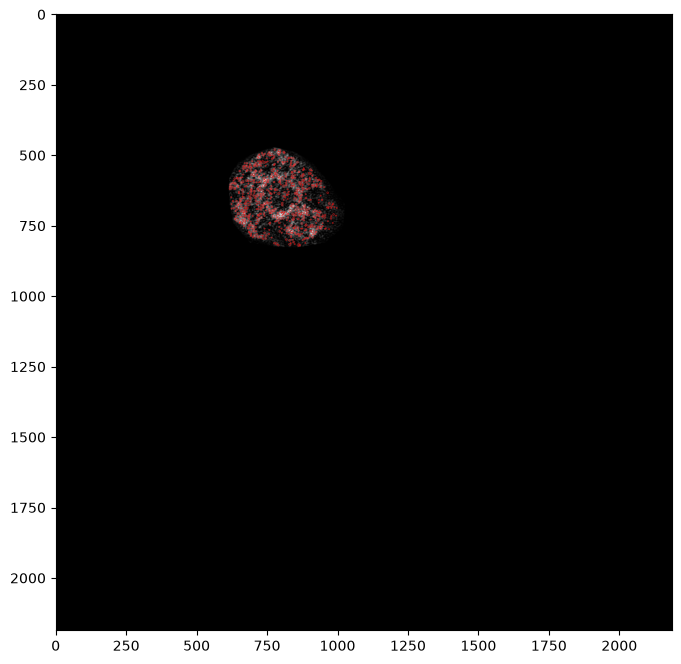

In [43]:
draw_foci(image_path, df=play, showplot = True, save_image = True, save_path = "30percent.png")